# Case-02：二次靜不定連續梁 (Two-Span Continuous Beam)

承接 Case-01，本 Case 新增一個節點 (B)，跨度從 1 跨變成 2 跨。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 兩跨連續梁，A端固定、B中間滾支承、C遠端滾支承 |
| AB跨 | L₁ = 5.0 m, w₁ = 15.0 kN/m |
| BC跨 | L₂ = 6.0 m, w₂ = 20.0 kN/m |
| 靜不定度 | 用傾角變位法的兩個未知數 θ_B, θ_C 求解 |
| 邊界/平衡條件 | θ_A=0 (固定端)，M_BA+M_BC=0 (中間節點平衡，新概念)，M_CB=0 (邊界條件，沿用Case-01) |

## 本 Case 新增的概念
B 是**連續**支承（不是鉸接），代表 AB 跨跟 BC 跨在 B 點共用同一個轉角 $\theta_B$——這是這題自由度選取最容易犯錯的地方（誤當成鉸接會多算出一個不存在的自由度），已經在步驟1的自由度區塊特別強調。需要新增**節點力矩平衡** $M_{BA}+M_{BC}=0$，C端沿用 Case-01 學過的邊界條件 $M_{CB}=0$。

## 驗證方式
結構受力圖 → 剪力圖(SFD) → 彎矩圖(BMD)，逐一跟 anastruct 比對，並做剪力交叉檢查。（教學詳解這個 Case 還沒實作，`print_teaching_handout()` 會優雅印出提示跳過。）

## 0. 安裝套件

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


## 1. 框架本體 (與 Case-01 共用)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod
from IPython.display import Markdown, display

sp.init_printing()


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


def member_shear_curve(s, length, w, M_i, M_j):
    """
    member_moment_curve 的對應剪力函式: V(s) = dM/ds = C1 + w*s
    (跟彎矩用同一個 C1，兩者必須自洽——這也是為什麼前幾輪都用剪力
    去反查彎矩圖畫法對不對的原因：M(s) 和 V(s) 本來就是同一個 C1
    推出來的，不會不一致)
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return C1 + w * s


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)：結構、幾何、材料、載重、邊界條件，用於步驟1。
        不含自由度選取的說明——那部分獨立在 describe_dof()。"""

    @abstractmethod
    def describe_dof(self) -> str:
        """
        自由度(未知位移量)選取的說明 (Markdown)，用於步驟1。跟 describe()
        分開成獨立方法，是因為這一步是整個傾角變位法最容易出錯、也最該
        覆核的地方——自由度選錯或漏掉一個，後面所有方程式都會建立在錯誤
        的基礎上，整題就全錯了，值得在輸出裡獨立成一個顯眼的區塊，
        不要被埋沒在結構描述裡面。
        """

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """
        回傳平衡方程式，用於步驟3。格式為 list[tuple[str, sp.Eq]]：
        每一條方程式搭配一句說明它是哪個節點/桿件、哪一種平衡條件
        (例如 "節點B力矩平衡 ΣM_B=0"、"C端邊界條件(滾支承) M_CB=0"、
        "整體水平力平衡 ΣFx=0")，求解器會把說明跟方程式一起印出來，
        不再只丟一堆沒有上下文的裸方程式。
        """

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""

    def draw_sfd(self, ax, moments_val: dict) -> bool:
        """
        (可選) 畫剪力圖 (SFD)，用於步驟6。若模型有實作，回傳 True 並把圖
        畫進傳入的 ax；預設不提供 (回傳 False)，求解器會印出提示而不出圖。
        """
        return False

    def teaching_breakdown(self, moments_val: dict, reactions: dict, solution: dict) -> list:
        """
        (可選) 回傳這個模型的「教學詳解 + 評分要點」分解，用於步驟8。
        每個小題是一個 dict，需要以下 key：
          - title:         小題標題 (str)
          - problem:       題目敘述 (str)
          - concept:       概念解析 (str)
          - formula:       公式引用 (str, 可含 LaTeX)
          - substitution:  帶入數據說明 (str)
          - answer:        詳細參考答案 (str, 可含 LaTeX)
          - keywords:       關鍵字/chunk 列表 (list[str])
          - grading:        評分要點列表 (list[tuple[str, int]])，每項是
                            (要點敘述, 配分)
        預設回傳空列表 (不提供)，求解器會印出提示而不出教學詳解——
        這是刻意設計成可選的，因為每題的概念解析、配分是需要針對該
        Case 手動設計的教學內容，不是所有 Case 一開始就要準備好。
        """
        return []


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def _solve_core(self):
        """純計算，不印任何東西：算出 moments、平衡方程式、解、回代結果、反力。
        solve_and_report() 跟 print_teaching_handout() 共用這段，避免兩邊各算一次
        還可能算出不一樣結果的風險。"""
        p = self.problem
        moments = p.build_moment_equations()
        labeled_eqs = p.build_equilibrium_equations(moments)
        eqs = [eq for _, eq in labeled_eqs]
        unknowns = p.get_unknowns()
        sol = sp.solve(eqs, tuple(unknowns.values()))
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        reactions = p.compute_reactions(moments_val)
        return moments, labeled_eqs, unknowns, sol, moments_val, reactions

    def _print_teaching_breakdown(self, moments_val, reactions, sol):
        """渲染 teaching_breakdown() 的內容 (題目/概念解析/公式引用/帶入數據/
        參考答案/關鍵字/評分要點)。solve_and_report() 的步驟8跟
        print_teaching_handout() 共用這段渲染邏輯，回傳 True/False 代表這個
        model 有沒有提供內容。"""
        p = self.problem
        breakdown = p.teaching_breakdown(moments_val, reactions, sol)
        if not breakdown:
            return False
        total_points = 0
        for i, item in enumerate(breakdown, 1):
            display(Markdown(f"### 第{i}小題：{item['title']}"))
            display(Markdown(f"**題目**：{item['problem']}"))
            display(Markdown(f"**概念解析**：{item['concept']}"))
            display(Markdown(f"**公式引用**：\n\n{item['formula']}"))
            display(Markdown(f"**帶入數據**：{item['substitution']}"))
            display(Markdown(f"**詳細參考答案**：\n\n{item['answer']}"))
            display(Markdown(f"**關鍵字/chunk**：{', '.join(item['keywords'])}"))
            pts_sum = sum(pts for _, pts in item['grading'])
            grading_lines = "\n".join(f"- {desc}（{pts}分）" for desc, pts in item['grading'])
            display(Markdown(f"**評分要點**（本小題共 {pts_sum} 分）：\n\n{grading_lines}"))
            total_points += pts_sum
        display(Markdown(f"---\n**本題總分：{total_points} 分**"))
        return True

    def print_teaching_handout(self):
        """
        產生一份可以直接複製當教學講義用的輸出，只有三塊、沒有步驟編號、
        沒有中間的符號方程式/平衡方程式這些過程 (那些留在 solve_and_report()
        裡)：
          1. 結構受力圖
          2. 教學詳解與評分要點 (原本步驟8的內容)
          3. 剪力圖(SFD) + 彎矩圖(BMD)
        適合放在 solve_and_report() 那個 cell 的下一個 cell，單獨執行、
        單獨截圖/複製，不用夾雜求解過程。
        """
        p = self.problem
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()

        display(Markdown("## 1. 結構受力圖與自由度"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        plt.show()
        display(Markdown(
            "**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        display(Markdown("## 2. 教學詳解與評分要點"))
        has_breakdown = self._print_teaching_breakdown(moments_val, reactions, sol)
        if not has_breakdown:
            print("(此模型尚未提供教學詳解)")

        display(Markdown("## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)"))
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            plt.show()
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        plt.show()
        plt.close('all')

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown("**① 結構定義、幾何與邊界條件**"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        plt.show()
        display(Markdown(
            "**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        display(Markdown(
            "**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：\n\n"
            r"$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$"
            "\n\n其中 $\\theta_i,\\theta_j$ 為兩端轉角，$\\psi=\\Delta/L$ 為側移角"
            "（無側移時 $\\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。"
        ))
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()
        display(Markdown(
            "**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式："
        ))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        display(Markdown("**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）："))
        for label, eq in labeled_eqs:
            display(Markdown(f"- {label}"))
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        display(Markdown("**位移求解結果：**"))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：剪力圖 (SFD) ----------------
        self._step_header(6, "繪製剪力圖 (SFD)")
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            plt.show()
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        # ---------------- 步驟7：彎矩圖 (BMD) ----------------
        self._step_header(7, "繪製彎矩圖 (BMD)")
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        plt.show()
        plt.close('all')

        # 教學詳解與評分要點已移到 print_teaching_handout()，這裡不再重複
        # (solve_and_report() 專注在「手算過程」，教學詳解是另一種呈現方式)

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-02 模型 (Strategy)

In [3]:
import numpy as np
import sympy as sp




class TwoSpanBeamProblem(SlopeDeflectionProblem):
    """
    Case-02：二次靜不定連續梁 (Two-Span Continuous Beam)
    A端固定 (theta_A=0)，B為中間滾支承 (連續、不釋放彎矩，theta_B 兩跨共用)，
    C為遠端滾支承 (M_CB=0)。AB跨、BC跨上各自承受均佈載重 w1、w2。

    本 Case 相對 Case-01 新增的概念：**中間節點的平衡方程式**
    (M_BA+M_BC=0，跟前面側移剛架、二層剛架的節點平衡是同一件事)，
    C端沿用 Case-01 學過的「邊界條件 M=0」。
    """

    def __init__(self, L1=5.0, L2=6.0, w1=15.0, w2=20.0):
        self.L1, self.L2, self.w1, self.w2 = L1, L2, w1, w2
        self.EI = sp.Symbol('EI', positive=True, real=True)
        self.theta_B, self.theta_C = sp.symbols('theta_B theta_C', real=True)

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B, '\\theta_C': self.theta_C}

    def describe(self):
        return (f"**AB跨** $L_1={self.L1}$ m ($w_1={self.w1}$ kN/m), "
                f"**BC跨** $L_2={self.L2}$ m ($w_2={self.w2}$ kN/m)\n\n"
                f"**邊界條件：** A端固定 ($\\theta_A=0$)，B為中間滾支承 "
                f"(連續，$\\theta_B$ 兩跨共用)，C為遠端滾支承 ($M_{{CB}}=0$)")

    def describe_dof(self):
        return (f"A端固定，$\\theta_A=0$，不是未知量；B是**連續**的中間支承"
                f"(不是鉸接釋放)，AB跨跟BC跨在B點共用**同一個**轉角 "
                f"$\\theta_B$——這裡如果誤把AB跨、BC跨各自設一個獨立轉角"
                f"(當成B是鉸接)，會多出一個不存在的自由度，方程式數量對不上；"
                f"C端是滾支承可自由轉動，$\\theta_C$ 是第二個未知量。"
                f"共兩個未知位移量 $\\theta_B, \\theta_C$——比 Case-01 多了一個"
                f"節點(B)，新增的是**中間節點力矩平衡** $M_{{BA}}+M_{{BC}}=0$。")

    def draw_geometry(self, ax):
        L1, L2, w1, w2 = self.L1, self.L2, self.w1, self.w2
        Ltot = L1 + L2
        ax.plot([0, Ltot], [0, 0], 'k-', lw=4)
        # A端固定
        ax.plot([0, 0], [-0.3, 0.3], 'k-', lw=3)
        for dy in np.linspace(-0.25, 0.25, 6):
            ax.plot([-0.15, 0], [dy - 0.15, dy], 'k-', lw=1)
        ax.text(0, -0.55, 'A (Fixed)', ha='center', fontsize=11, fontweight='bold')
        # B中間滾支承
        ax.plot(L1, -0.12, 'o', color='white', mec='k', ms=14, mew=2)
        ax.plot([L1 - 0.25, L1 + 0.25], [-0.28, -0.28], 'k-', lw=2)
        ax.text(L1, -0.55, 'B (Roller)', ha='center', fontsize=11, fontweight='bold')
        # C遠端滾支承
        ax.plot(Ltot, -0.12, 'o', color='white', mec='k', ms=14, mew=2)
        ax.plot([Ltot - 0.25, Ltot + 0.25], [-0.28, -0.28], 'k-', lw=2)
        ax.text(Ltot, -0.55, 'C (Roller)', ha='center', fontsize=11, fontweight='bold')
        # 均佈載重箭頭 (兩跨分開畫,數值不同)
        for x in np.linspace(0.3, L1 - 0.3, 6):
            ax.annotate('', xy=(x, 0.05), xytext=(x, 0.4),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
        ax.text(L1 / 2, 0.55, f'$w_1={w1}$ kN/m', color='red', ha='center', fontsize=10)
        for x in np.linspace(L1 + 0.3, Ltot - 0.3, 7):
            ax.annotate('', xy=(x, 0.05), xytext=(x, 0.4),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
        ax.text(L1 + L2 / 2, 0.55, f'$w_2={w2}$ kN/m', color='red', ha='center', fontsize=10)
        # theta_B, theta_C 標示 (箭頭跟文字對齊在同一位置)
        ax.annotate('', xy=(L1 - 0.3, -0.75), xytext=(L1 + 0.3, -0.75),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(L1, -1.05, r'$\theta_B$', color='purple', fontsize=13, ha='center')
        ax.annotate('', xy=(Ltot - 0.3, -0.75), xytext=(Ltot + 0.3, -0.75),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(Ltot, -1.05, r'$\theta_C$', color='purple', fontsize=13, ha='center')

        ax.set_xlim(-1.5, Ltot + 1.5)
        ax.set_ylim(-1.3, 1.0)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: Two-Span Continuous Beam — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, L1, L2, w1, w2 = self.EI, self.L1, self.L2, self.w1, self.w2
        thB, thC = self.theta_B, self.theta_C
        FEM_AB = w1 * L1**2 / 12
        FEM_BA = -w1 * L1**2 / 12
        FEM_BC = w2 * L2**2 / 12
        FEM_CB = -w2 * L2**2 / 12
        return {
            'M_{AB}': 2 * EI / L1 * thB + FEM_AB,
            'M_{BA}': 2 * EI / L1 * (2 * thB) + FEM_BA,
            'M_{BC}': 2 * EI / L2 * (2 * thB + thC) + FEM_BC,
            'M_{CB}': 2 * EI / L2 * (thB + 2 * thC) + FEM_CB,
        }

    def build_equilibrium_equations(self, moments):
        eq1 = sp.Eq(moments['M_{BA}'] + moments['M_{BC}'], 0)
        eq2 = sp.Eq(moments['M_{CB}'], 0)
        return [
            ("節點 B 力矩平衡 ΣM_B=0（AB跨與BC跨在B點交會，連續支承、無外加彎矩） "
             "M_BA + M_BC = 0", eq1),
            ("C端邊界條件（滾支承不傳彎矩） M_CB = 0", eq2),
        ]

    def compute_reactions(self, moments_val):
        L1, L2, w1, w2 = self.L1, self.L2, self.w1, self.w2
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        # 遠端要negate才是物理上連續的邊界值(已用剪力對過anastruct)
        V_ab_0 = member_shear_curve(0.0, L1, w1, m_ab, -m_ba)
        V_ab_L = member_shear_curve(L1, L1, w1, m_ab, -m_ba)
        V_bc_0 = member_shear_curve(0.0, L2, w2, m_bc, -m_cb)
        V_bc_L = member_shear_curve(L2, L2, w2, m_bc, -m_cb)
        R_A = -V_ab_0
        R_B = V_ab_L - V_bc_0
        R_C = V_bc_L
        return {'R_A (kN)': R_A, 'R_B (kN)': R_B, 'R_C (kN)': R_C}

    def draw_sfd(self, ax, moments_val):
        L1, L2, w1, w2 = self.L1, self.L2, self.w1, self.w2
        Ltot = L1 + L2
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        scale = 0.015

        ax.plot([0, Ltot], [0, 0], 'k-', lw=4, label='Beam')
        x1 = np.linspace(0, L1, 100)
        v1 = member_shear_curve(x1, L1, w1, m_ab, -m_ba)
        ax.plot(x1, v1 * scale, 'b-', lw=2, label='SFD (kN)')
        ax.fill_between(x1, 0, v1 * scale, color='blue', alpha=0.15)

        x2 = np.linspace(0, L2, 100)
        v2 = member_shear_curve(x2, L2, w2, m_bc, -m_cb)
        ax.plot(L1 + x2, v2 * scale, 'b-', lw=2)
        ax.fill_between(L1 + x2, 0, v2 * scale, color='blue', alpha=0.15)

        for x, y, val in [(0, v1[0], v1[0]), (L1, v1[-1], v1[-1]),
                          (L1, v2[0], v2[0]), (Ltot, v2[-1], v2[-1])]:
            ax.text(x, y * scale + (0.3 if val > 0 else -0.3), f'{val:.1f}',
                    color='darkblue', ha='center', fontweight='bold', fontsize=9)

        ax.axvline(L1, color='gray', lw=0.6, zorder=0)
        ax.set_xlim(-1, Ltot + 1)
        ax.set_title('Figure: Shear Force Diagram (SFD) [kN]')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Shear offset (scaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        return True

    @staticmethod
    def _label_interior_extremum(ax, x_arr, m_arr, length, w, M_i, M_j, scale, x_offset):
        """
        用解析解找拋物線 M(s)=M_i+C1*s+0.5*w*s^2 的跨內真正極值 (頂點 s*=-C1/w)，
        只有 s* 落在 (0, length) 內才是真正的跨內極值才標註——如果落在跨外
        (或 w=0 沒有均佈載重、根本是直線)，代表這跨的極值就在端點，那裡已經
        各自標過了，不用再多標一個假的"跨內"標籤 (之前用陣列掃描+排除邊界
        margin 的做法，找到的常常只是margin邊緣的點，不是真正的極值，已改掉)。
        """
        if w == 0:
            return
        C1 = (M_j - M_i - 0.5 * w * length**2) / length
        s_star = -C1 / w
        if 0 < s_star < length:
            m_star = M_i + C1 * s_star + 0.5 * w * s_star**2
            ax.text(x_offset + s_star, m_star * scale + (0.3 if m_star > 0 else -0.3),
                    f'{m_star:.2f}\n(x={s_star:.2f}m)', color='darkred',
                    ha='center', fontweight='bold', fontsize=9)

    def draw_bmd(self, ax, moments_val):
        L1, L2, w1, w2 = self.L1, self.L2, self.w1, self.w2
        Ltot = L1 + L2
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        scale = 0.025

        ax.plot([0, Ltot], [0, 0], 'k-', lw=4, label='Beam')

        x1 = np.linspace(0, L1, 200)
        # 遠端(B)要negate才是物理連續的邊界值 — 已用剪力驗證過 (見上方 compute_reactions)
        m1 = member_moment_curve(x1, L1, w1, m_ab, -m_ba)
        ax.plot(x1, m1 * scale, 'r--', lw=2, label='BMD (kN·m)')
        ax.fill_between(x1, 0, m1 * scale, color='red', alpha=0.15)

        x2 = np.linspace(0, L2, 200)
        m2 = member_moment_curve(x2, L2, w2, m_bc, -m_cb)
        ax.plot(L1 + x2, m2 * scale, 'r--', lw=2)
        ax.fill_between(L1 + x2, 0, m2 * scale, color='red', alpha=0.15)

        ax.text(0, m_ab * scale - 0.3, f'{m_ab:.2f}', color='darkred', ha='center', fontweight='bold')
        self._label_interior_extremum(ax, x1, m1, L1, w1, m_ab, -m_ba, scale, x_offset=0)
        self._label_interior_extremum(ax, x2, m2, L2, w2, m_bc, -m_cb, scale, x_offset=L1)
        ax.text(Ltot, m_cb * scale - 0.3, f'{m_cb:.2f}', color='darkred', ha='center', fontweight='bold')

        ax.axvline(L1, color='gray', lw=0.6, zorder=0)
        ax.set_xlim(-1, Ltot + 1)
        ax.set_title('Figure: Bending Moment Diagram (BMD) [kN·m]')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Moment offset (scaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')


## 3. 求解並產生「手寫詳解」風格輸出


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**AB跨** $L_1=5.0$ m ($w_1=15.0$ kN/m), **BC跨** $L_2=6.0$ m ($w_2=20.0$ kN/m)

**邊界條件：** A端固定 ($\theta_A=0$)，B為中間滾支承 (連續，$\theta_B$ 兩跨共用)，C為遠端滾支承 ($M_{CB}=0$)

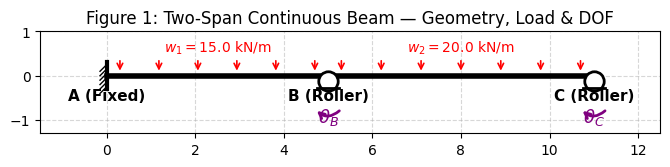

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，$\theta_A=0$，不是未知量；B是**連續**的中間支承(不是鉸接釋放)，AB跨跟BC跨在B點共用**同一個**轉角 $\theta_B$——這裡如果誤把AB跨、BC跨各自設一個獨立轉角(當成B是鉸接)，會多出一個不存在的自由度，方程式數量對不上；C端是滾支承可自由轉動，$\theta_C$ 是第二個未知量。共兩個未知位移量 $\theta_B, \theta_C$——比 Case-01 多了一個節點(B)，新增的是**中間節點力矩平衡** $M_{BA}+M_{BC}=0$。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（AB跨與BC跨在B點交會，連續支承、無外加彎矩） M_BA + M_BC = 0

- C端邊界條件（滾支承不傳彎矩） M_CB = 0


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = 13.173 kN·m
M_{BA} = -67.404 kN·m
M_{BC} = 67.404 kN·m
M_{CB} = 0.000 kN·m

-> R_A (kN) = 26.654
-> R_B (kN) = 119.580
-> R_C (kN) = 48.766

【步驟 6】繪製剪力圖 (SFD)


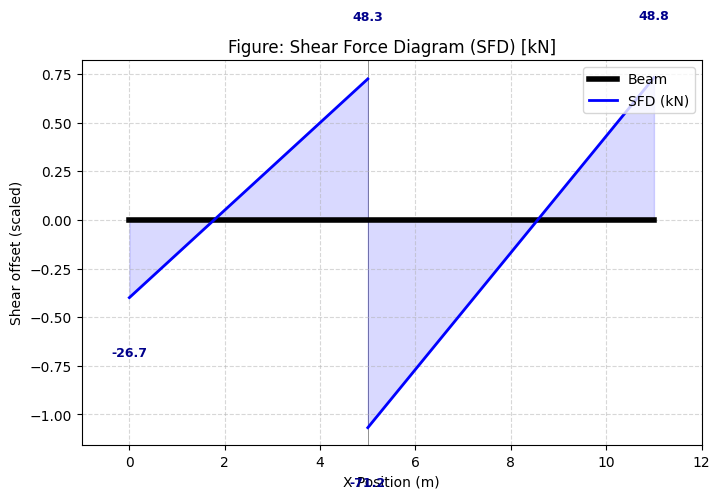


【步驟 7】繪製彎矩圖 (BMD)


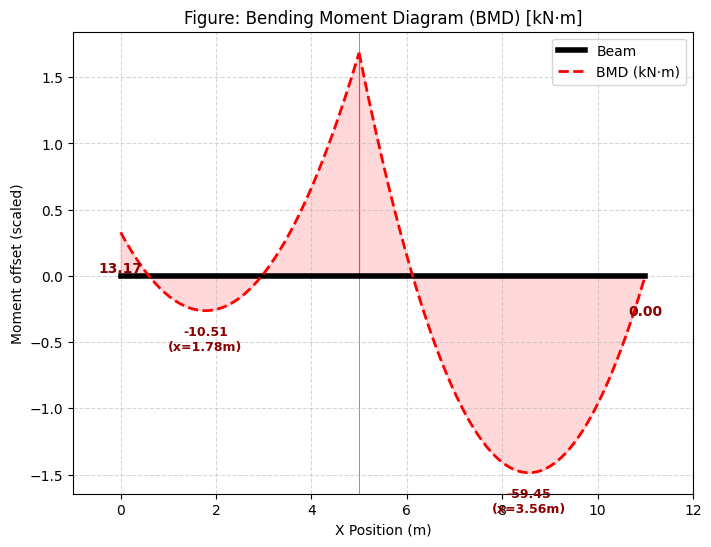

{'moments': {'M_{AB}': 13.173076923076923,
  'M_{BA}': -67.40384615384616,
  'M_{BC}': 67.40384615384615,
  'M_{CB}': 0.0},
 'reactions': {'R_A (kN)': 26.653846153846153,
  'R_B (kN)': 119.5801282051282,
  'R_C (kN)': 48.76602564102565},
 'solution': {theta_B: -45.1923076923077/EI, theta_C: 112.596153846154/EI}}

In [4]:
problem = TwoSpanBeamProblem(L1=5.0, L2=6.0, w1=15.0, w2=20.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 3b. 教學講義輸出（此 Case 教學詳解尚未實作，示範優雅跳過）

## 1. 結構受力圖與自由度

**AB跨** $L_1=5.0$ m ($w_1=15.0$ kN/m), **BC跨** $L_2=6.0$ m ($w_2=20.0$ kN/m)

**邊界條件：** A端固定 ($\theta_A=0$)，B為中間滾支承 (連續，$\theta_B$ 兩跨共用)，C為遠端滾支承 ($M_{CB}=0$)

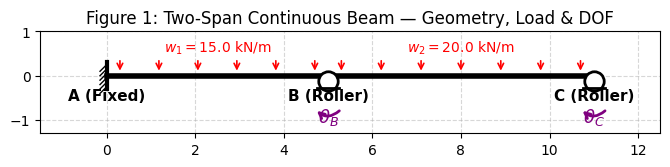

**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，$\theta_A=0$，不是未知量；B是**連續**的中間支承(不是鉸接釋放)，AB跨跟BC跨在B點共用**同一個**轉角 $\theta_B$——這裡如果誤把AB跨、BC跨各自設一個獨立轉角(當成B是鉸接)，會多出一個不存在的自由度，方程式數量對不上；C端是滾支承可自由轉動，$\theta_C$ 是第二個未知量。共兩個未知位移量 $\theta_B, \theta_C$——比 Case-01 多了一個節點(B)，新增的是**中間節點力矩平衡** $M_{BA}+M_{BC}=0$。

## 2. 教學詳解與評分要點

(此模型尚未提供教學詳解)


## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)

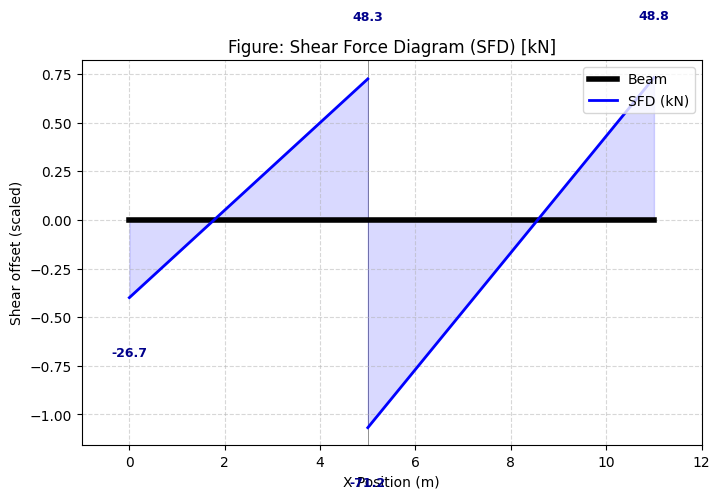

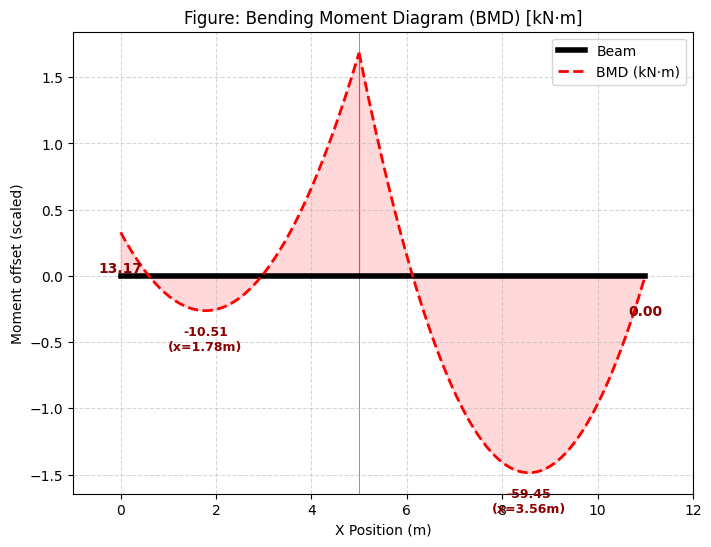

In [5]:
solver.print_teaching_handout()

## 4. anastruct 獨立建模驗證

A反力: {'id': 1, 'Fx': np.float64(-1.1940306291686696e-14), 'Fy': np.float64(-26.653851576920367), 'Tz': np.float64(-13.173070336541748), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
B反力: {'id': 2, 'Fx': np.float64(0.0), 'Fy': np.float64(-119.5801171650696), 'Tz': np.float64(1.4210854715202004e-14), 'ux': np.float64(4.822046771642705e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(0.0030128190064110105)}
C反力: {'id': 3, 'Fx': np.float64(1.5777218104420236e-30), 'Fy': np.float64(-48.766031258010024), 'Tz': np.float64(0.0), 'ux': np.float64(7.02641101010794e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0075064065032070006)}


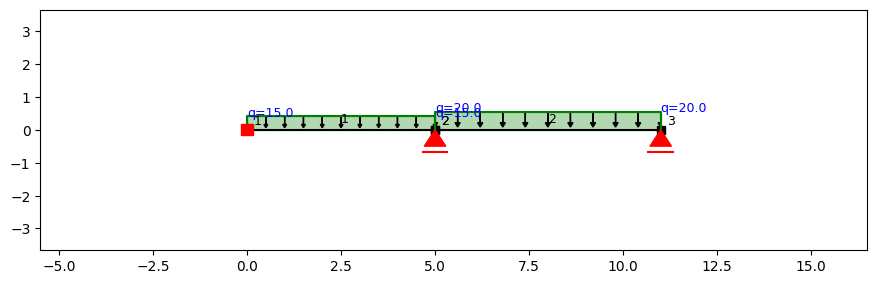

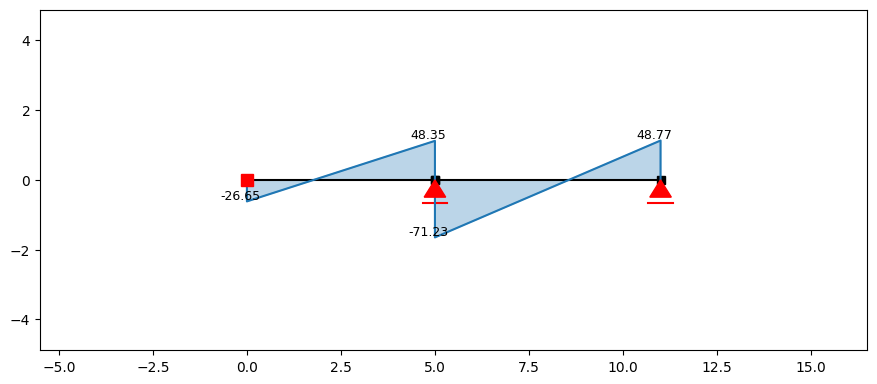

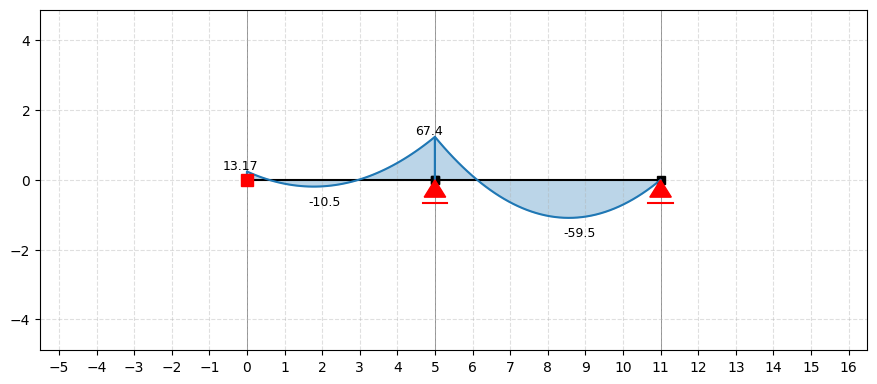

In [6]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L1, L2, w1, w2 = 5.0, 6.0, 15.0, 20.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [L1, 0]])
ss.add_element(location=[[L1, 0], [L1 + L2, 0]])
ss.add_support_fixed(node_id=1)
ss.add_support_roll(node_id=2, direction='x')
ss.add_support_roll(node_id=3, direction='x')
ss.q_load(element_id=1, q=-w1)
ss.q_load(element_id=2, q=-w2)
ss.solve()

print("A反力:", ss.get_node_results_system(1))
print("B反力:", ss.get_node_results_system(2))
print("C反力:", ss.get_node_results_system(3))

ss.show_structure(figsize=(9, 3))
ss.show_shear_force(figsize=(9, 4))

fig = ss.show_bending_moment(show=False, figsize=(9, 4))
ax = fig.axes[0]
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', lw=0.6, zorder=0)
ax.axvline(L1, color='gray', lw=0.6, zorder=0)
ax.axvline(L1 + L2, color='gray', lw=0.6, zorder=0)
plt.show()

## 5. 剪力交叉檢查（AB跨、BC跨都要各自檢查兩端）

In [7]:
m_ab, m_ba = 13.173076923076923, -67.40384615384616
m_bc, m_cb = 67.40384615384615, 0.0

V_ab0 = member_shear_curve(0.0, L1, w1, m_ab, -m_ba)
V_abL = member_shear_curve(L1, L1, w1, m_ab, -m_ba)
V_bc0 = member_shear_curve(0.0, L2, w2, m_bc, -m_cb)
V_bcL = member_shear_curve(L2, L2, w2, m_bc, -m_cb)
print(f"我們框架推算剪力: AB(0)={V_ab0:.3f} AB(L)={V_abL:.3f}  BC(0)={V_bc0:.3f} BC(L)={V_bcL:.3f}")

el1, el2 = ss.element_map[1], ss.element_map[2]
print(f"anastruct 實際剪力: AB(0)={el1.shear_force[0]:.3f} AB(L)={el1.shear_force[-1]:.3f}  "
      f"BC(0)={el2.shear_force[0]:.3f} BC(L)={el2.shear_force[-1]:.3f}")

assert abs(V_ab0 - el1.shear_force[0]) < 0.01
assert abs(V_abL - el1.shear_force[-1]) < 0.01
assert abs(V_bc0 - el2.shear_force[0]) < 0.01
assert abs(V_bcL - el2.shear_force[-1]) < 0.01
print("\n剪力交叉檢查通過 ✓ (兩跨、四個端點全部核對)")

我們框架推算剪力: AB(0)=-26.654 AB(L)=48.346  BC(0)=-71.234 BC(L)=48.766
anastruct 實際剪力: AB(0)=-26.654 AB(L)=48.346  BC(0)=-71.234 BC(L)=48.766

剪力交叉檢查通過 ✓ (兩跨、四個端點全部核對)
